# Introduction

Superconductivity is a phenomenon in which a material exhibits zero electrical resistance and expels magnetic fields when cooled below a certain temperature, known as the critical temperature.The dataset used in this study was obtained from the Kaggle [Superconductivity dataset](https://www.kaggle.com/datasets/tunguz/superconductivty-data-data-set). It contains 21,263 observations and 82 columns, where the target variable is the critical temperature. The remaining columns represent various material property features, including atomic mass, valence, density, electron affinity, fusion heat, and thermal conductivity.This dataset is used to develop machine learning models to predict the critical temperature of superconducting materials.

# Methodology
1. Data preprocessing
2. Train-test split
3. Model training
4. Hyperparamter tuning
5. Model Evaluation
6. Model comparrison











#Import important libraries

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#Load Dataset

In [18]:
df1= pd.read_csv('train.csv')

In [19]:
df1.isna()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21258,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21259,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21260,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21261,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

In [21]:
df1.head()


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [22]:
df1.duplicated().sum()

np.int64(66)

In [23]:
df = df1.drop_duplicates()

In [24]:
X=df.drop('critical_temp',axis =1).values
y= df['critical_temp'].values

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30,random_state=42)

In [26]:
df_feat = pd.DataFrame(X_train ,columns=df.columns[:-1])
df_feat.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence
0,4.0,76.444563,52.364594,59.356672,35.812204,1.199541,1.286888,121.327600,14.741917,43.823354,...,2.250000,2.079365,2.213364,2.065406,1.368922,1.218033,1.0,0.809524,0.433013,0.270308
1,2.0,96.147000,92.307060,96.020881,92.258323,0.691836,0.367806,9.846000,70.071660,4.923000,...,5.000000,4.220000,4.898979,4.182443,0.673012,0.433649,2.0,2.900000,1.000000,0.625780
2,3.0,74.872065,74.674186,73.328944,74.032951,1.077521,0.595191,37.026805,55.306934,15.548435,...,4.333333,3.584000,4.160168,3.434935,1.057905,0.675478,3.0,2.368000,1.247219,1.181077
3,4.0,76.797975,62.090874,68.845615,59.976355,1.276357,1.104102,98.228700,27.222100,37.173836,...,2.750000,3.420000,2.340347,2.995416,1.240684,0.888219,4.0,1.960000,1.479020,1.470918
4,6.0,79.192832,59.187498,59.410215,36.104402,1.523721,1.402407,192.981000,27.392588,62.040962,...,2.833333,2.416000,2.615321,2.272463,1.707475,1.411735,3.0,1.034667,1.213352,1.029050


In [27]:
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor()
dtree.fit(X_train,y_train)


DecisionTreeRegressor()

In [28]:
predictions1 = dtree.predict(X_test)

In [29]:
print('MAE:', mean_absolute_error(y_test, predictions1))
print('MSE:', mean_squared_error(y_test, predictions1))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions1)))
print('r^2:', r2_score(y_test, predictions1))

MAE: 6.245588956009511
MSE: 147.08526970166673
RMSE: 12.127871606414159
r^2: 0.8751801193878869


Text(0, 0.5, 'Predicted Y')

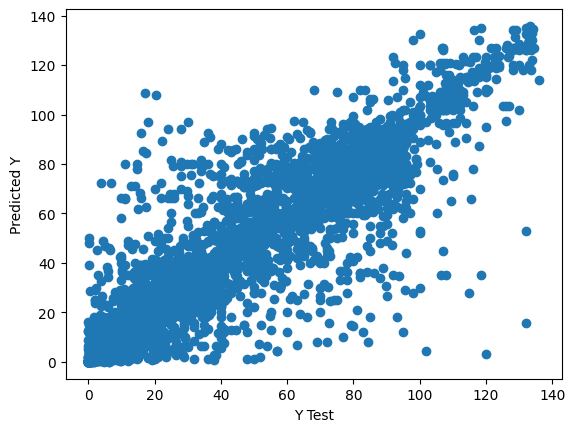

In [30]:
plt.scatter(y_test,predictions1)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
# print(y_test, predictions1)

#Random Forest Regressor


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [32]:
rfr = RandomForestRegressor( n_estimators=400 )

In [33]:
rfr.fit(X_train,y_train)

RandomForestRegressor(n_estimators=400)

In [34]:
predictions2 = rfr.predict(X_test)

MAE: 5.340007872797657
MSE: 93.66060053247844
RMSE: 9.677840695758452
r^2: 0.9205174998133052


Text(0, 0.5, 'Predicted Y')

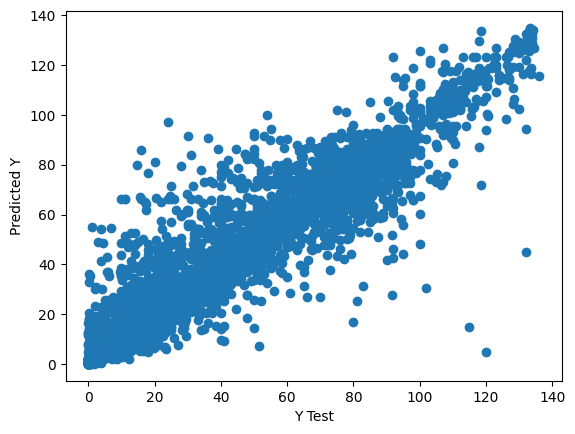

In [35]:
print('MAE:', mean_absolute_error(y_test, predictions2))
print('MSE:', mean_squared_error(y_test, predictions2))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions2)))
print('r^2:', r2_score(y_test, predictions2))
plt.scatter(y_test,predictions2)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
# print(y_test, predictions2)

# Gradient Boost Regressor

MAE: 7.534322395497128
MSE: 135.5492390783024
RMSE: 11.64256153422873
r^2: 0.8849698554237702


Text(0, 0.5, 'Predicted Y')

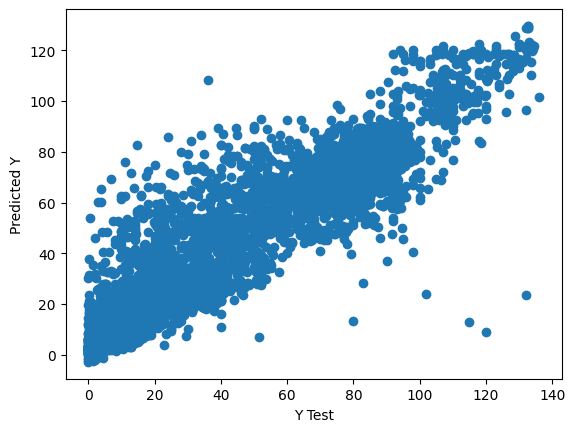

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
GBR_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3
)

GBR_model.fit(X_train, y_train)

predictions4 = GBR_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, predictions4))
print('MSE:', mean_squared_error(y_test, predictions4))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions4)))
print('r^2:', r2_score(y_test, predictions4))
plt.scatter(y_test,predictions4)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
# print(y_test, predictions4)

In [37]:
from xgboost import XGBRegressor
from  sklearn.model_selection import RandomizedSearchCV

In [38]:

xgb_model= XGBRegressor(objective='reg:squarederror',random_state =42)

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}




In [39]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,      # number of random combinations
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)


In [40]:
random_search_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2')

In [41]:
predictions3 = random_search_xgb.predict(X_test)

MAE: 5.428461554566488
MSE: 87.95680742129323
RMSE: 9.378529064906353
r^2: 0.9253578674219609


Text(0, 0.5, 'Predicted Y')

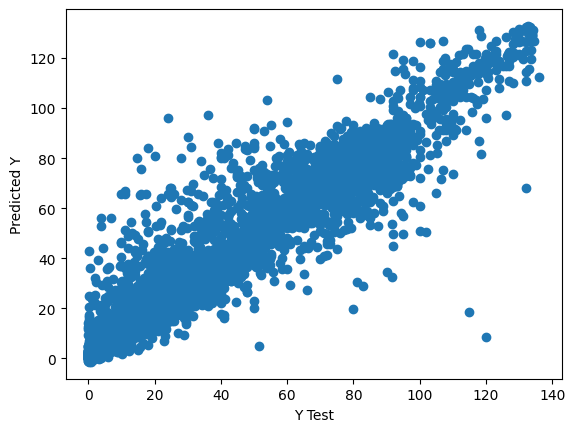

In [42]:
print('MAE:', mean_absolute_error(y_test, predictions3))
print('MSE:', mean_squared_error(y_test, predictions3))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions3)))
print('r^2:', r2_score(y_test, predictions3))
plt.scatter(y_test,predictions3)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
# print(y_test, predictions3)

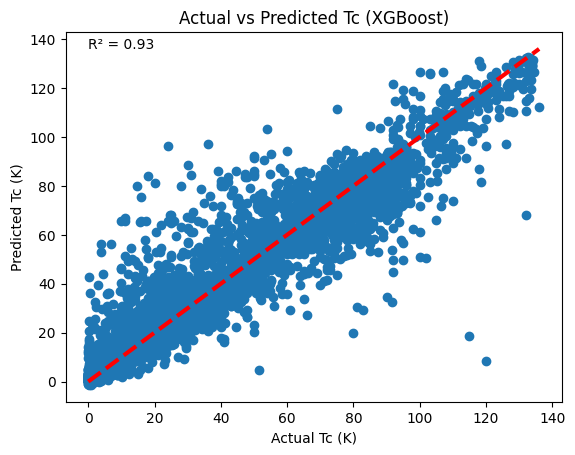

In [73]:

plt.scatter(y_test, predictions3)

plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
        linestyle='--',linewidth=3 ,color ='red')

plt.text(min(y_test), max(y_test), f"R² = {r2_score(y_test, predictions3):.2f}")

plt.xlabel("Actual Tc (K)")
plt.ylabel("Predicted Tc (K)")
plt.title("Actual vs Predicted Tc (XGBoost)")

plt.show()

# Results

In [74]:
results  =  {'Model': ['DecisionTreeRegressor','Random Forest','Gradient Boosting', 'XGBoost'],
             "r2":[r2_score(y_test, predictions1),r2_score(y_test, predictions2),r2_score(y_test, predictions4), r2_score(y_test, predictions3) ],
             "MAE":[mean_absolute_error(y_test, predictions1),mean_absolute_error(y_test, predictions2),mean_absolute_error(y_test, predictions4),mean_absolute_error(y_test, predictions3)],
             "MASE":[mean_squared_error(y_test, predictions1),mean_squared_error(y_test, predictions2),mean_squared_error(y_test, predictions4),mean_squared_error(y_test, predictions3)],
             "RMSE" :[np.sqrt(mean_squared_error(y_test, predictions1)),np.sqrt(mean_squared_error(y_test, predictions2)),np.sqrt(mean_squared_error(y_test, predictions4)),np.sqrt(mean_squared_error(y_test, predictions3))]}

In [75]:
df_results=  pd.DataFrame(results)
df_results

,Model,r2,MAE,MASE,RMSE
0,DecisionTreeRegressor,0.875180,6.245589,147.085270,12.127872
1,Random Forest,0.920517,5.340008,93.660601,9.677841
2,Gradient Boosting,0.884970,7.534322,135.549239,11.642562
3,XGBoost,0.925358,5.428462,87.956807,9.378529


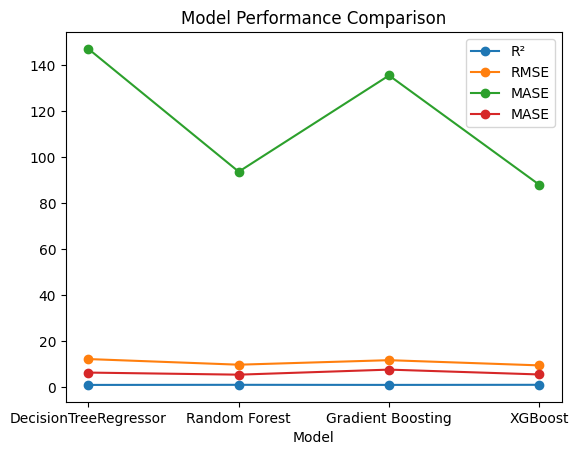

In [79]:
plt.figure()

plt.plot(df_results["Model"], df_results["r2"], marker='o', label="R²")
plt.plot(df_results["Model"], df_results["RMSE"], marker='o', label="RMSE")
plt.plot(df_results["Model"], df_results["MASE"], marker='o', label="MASE")
plt.plot(df_results["Model"], df_results["MAE"], marker='o', label="MASE")
plt.xlabel("Model")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

#Conclusion

Among the different models, performance was evaluated using R² and RMSE metrics. XGBoost achieved the highest R² and the lowest RMSE, indicating superior predictive performance compared to the other models.